# Advanced Error Analysis for Multi-modal RoBERTa

This notebook performs advanced error analysis for the multi-modal RoBERTa model used in the project:

**Detecting LLM-Generated Social Media Accounts Using Semantic and Textual Features**

The analysis includes:

1. Prediction distribution
2. Confusion matrix
3. False Positive / False Negative inspection
4. Shortcut feature analysis
5. Punctuation masking robustness
6. Class imbalance robustness
7. Confidence analysis
8. Final conclusions


## Load Dataset

Update the dataset path if needed.


In [7]:
import pandas as pd
import numpy as np
import torch
import re
import string
from transformers import AutoTokenizer
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

# load datasets
train_df = pd.read_csv(
    "train.csv",
    sep=";",
    engine="python",
    on_bad_lines="skip"
)

test_df = pd.read_csv(
    "test.csv",
    sep=";",
    engine="python",
    on_bad_lines="skip"
)

print(train_df.head())
print(test_df.head())

text_col = "text"
label_col = "account.type"

# binary labels
train_df["label_numeric"] = train_df[label_col].apply(
    lambda x: 0 if x == "human" else 1
)

test_df["label_numeric"] = test_df[label_col].apply(
    lambda x: 0 if x == "human" else 1
)

print(test_df[[text_col, label_col, "label_numeric"]].head())

      screen_name                                               text  \
0      imranyebot                             YEA now that note GOOD   
1          zawvrk  Listen to This Charming Man by The Smiths  htt...   
2        zawarbot  wish i can i would be seeing other hoes on the...   
3  ahadsheriffbot  The decade in the significantly easier schedul...   
4   kevinhookebot  "Theim class=\"alignnone size-full wp-image-60...   

  account.type class_type  
0          bot     others  
1        human      human  
2          bot     others  
3          bot     others  
4          bot        rnn  
      screen_name                                               text  \
0          zawvrk  justin timberlake really one of the goats if y...   
1    narendramodi  Thank you @PMBhutan for your gracious prayers ...   
2     ahadsheriff  Theory: the number of red lights you will hit ...   
3  AINarendraModi  Respects on the Upt of the I good with the peo...   
4      kevinhooke  Might give the BASIC

## Metadata Feature Extraction



In [8]:
# metadata feature extraction

def extract_meta_features(text):
    text = str(text)
    length = len(text)

    return [
        int("http" in text.lower()),
        text.count("#"),
        text.count("@"),
        sum(c in string.punctuation for c in text),
        length,
        sum(c.isupper() for c in text) / (length + 1)
    ]

X_train_text = train_df[text_col]
X_test_text = test_df[text_col]

X_train_meta = np.array([
    extract_meta_features(t)
    for t in X_train_text
])

X_test_meta = np.array([
    extract_meta_features(t)
    for t in X_test_text
])

y_train = train_df["label_numeric"].values
y_test = test_df["label_numeric"].values

print(X_train_meta.shape)
print(X_test_meta.shape)

(20712, 6)
(2558, 6)


## Standardize Metadata

In [9]:
scaler = StandardScaler()

X_train_meta_scaled = scaler.fit_transform(X_train_meta)
X_test_meta_scaled = scaler.transform(X_test_meta)


#Tokenization

In [10]:
model_name = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)


def preprocess_for_transformer(texts, tokenizer, max_len=128):
    encoded = tokenizer(
        texts.tolist(),
        padding="max_length",
        truncation=True,
        max_length=max_len,
        return_tensors="pt"
    )

    return encoded["input_ids"], encoded["attention_mask"]

print("Tokenizing texts...")

train_ids, train_masks = preprocess_for_transformer(
    X_train_text,
    tokenizer
)

test_ids, test_masks = preprocess_for_transformer(
    X_test_text,
    tokenizer
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing texts...


## Create Dataloaders

In [11]:
meta_train_tensor = torch.tensor(
    X_train_meta_scaled,
    dtype=torch.float
)

meta_test_tensor = torch.tensor(
    X_test_meta_scaled,
    dtype=torch.float
)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(
        train_ids,
        train_masks,
        meta_train_tensor,
        y_train_tensor
    ),
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(
        test_ids,
        test_masks,
        meta_test_tensor,
        y_test_tensor
    ),
    batch_size=32,
    shuffle=False
)

print("Multi-modal dataloaders ready.")

Multi-modal dataloaders ready.


## Define Multi-modal RoBERTa Model

In [20]:
import torch.nn as nn
from transformers import AutoModel
from torch.optim import AdamW
MODEL_MODE = 'mean_pooling'
USE_METADATA = True
METADATA_DIM = 6
class MultiModalRoBERTa(nn.Module):
    def __init__(
        self,
        mode = 'mean_pooling',
        use_metadata = True,
        metadata_dim = 6
    ):
        super(MultiModalRoBERTa, self).__init__()
        self.mode = mode
        self.use_metadata = use_metadata
        self.roberta = AutoModel.from_pretrained(
            "roberta-base"
        )

        self.input_dim = 768 + (
            metadata_dim if use_metadata else 0
        )

        self.classifier = nn.Sequential(
            nn.Linear(self.input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 2)
        )

    def forward(
        self,
        input_ids,
        attention_mask,
        metadata_feats
    ):

        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        last_hidden = outputs.last_hidden_state

        if self.mode == 'base':
            pooled = last_hidden[:, 0, :]
        else:
            mask = attention_mask.unsqueeze(-1).expand(
                last_hidden.size()
            ).float()

            sum_embeddings = torch.sum(
                last_hidden * mask,
                1
            )

            sum_mask = torch.clamp(
                mask.sum(1),
                min=1e-9
            )

            pooled = sum_embeddings / sum_mask

        if self.use_metadata:
            final_features = torch.cat(
                (pooled, metadata_feats),
                dim=1
            )
        else:
            final_features = pooled

        return self.classifier(final_features)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = MultiModalRoBERTa(
    mode=MODEL_MODE,
    use_metadata=USE_METADATA,
    metadata_dim=METADATA_DIM
).to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Train Model

In [21]:
print(f"Running multi-modal training on {device}...")

for epoch in range(3):

    model.train()

    total_loss = 0

    for batch in train_loader:

        b_ids, b_masks, b_meta, b_labels = [
            t.to(device)
            for t in batch
        ]

        optimizer.zero_grad()

        logits = model(
            b_ids,
            b_masks,
            b_meta
        )

        loss = criterion(logits, b_labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1}, Loss: "
        f"{total_loss/len(train_loader):.4f}"
    )


Running multi-modal training on cuda...
Epoch 1, Loss: 0.2890
Epoch 2, Loss: 0.1835
Epoch 3, Loss: 0.1223


## Real Model Inference

In [22]:
import torch.nn.functional as F

model.eval()

all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():

    for batch in test_loader:

        b_ids, b_masks, b_meta, b_labels = [
            t.to(device)
            for t in batch
        ]

        logits = model(
            b_ids,
            b_masks,
            b_meta
        )

        probs = F.softmax(logits, dim=1)

        prob_ai = probs[:, 1]
        preds = torch.argmax(probs, dim=1)

        all_probs.extend(prob_ai.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(b_labels.cpu().numpy())


test_df["prob_ai"] = all_probs
test_df["pred"] = all_preds
test_df["label_numeric"] = all_labels

label_col = "label_numeric"

print(
    test_df[[
        "prob_ai",
        "pred",
        label_col
    ]].head()
)

print("Prediction finished.")


    prob_ai  pred  label_numeric
0  0.312243     0              0
1  0.000806     0              0
2  0.885747     1              0
3  0.999444     1              1
4  0.001077     0              0
Prediction finished.


#Confusion Matrix

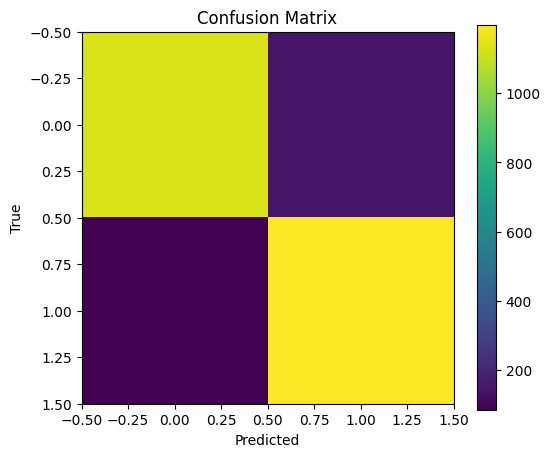

              precision    recall  f1-score   support

           0       0.93      0.89      0.91      1278
           1       0.89      0.94      0.91      1280

    accuracy                           0.91      2558
   macro avg       0.91      0.91      0.91      2558
weighted avg       0.91      0.91      0.91      2558

ROC-AUC: 0.9754


In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

cm = confusion_matrix(
    test_df[label_col],
    test_df["pred"]
)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(
    classification_report(
        test_df[label_col],
        test_df["pred"]
    )
)

auc = roc_auc_score(
    test_df[label_col],
    test_df["prob_ai"]
)

print("ROC-AUC:", round(auc, 4))

#False Positive / False Negative Analysis

In [24]:
false_positive = test_df[
    (test_df[label_col] == 0) &
    (test_df["pred"] == 1)
]

false_negative = test_df[
    (test_df[label_col] == 1) &
    (test_df["pred"] == 0)
]

print("False Positives:", len(false_positive))
print("False Negatives:", len(false_negative))

print("\n=== Sample False Positives ===")
for t in false_positive[text_col].head(3):
    print("\n", t[:500])

print("\n=== Sample False Negatives ===")
for t in false_negative[text_col].head(3):
    print("\n", t[:500])

False Positives: 145
False Negatives: 83

=== Sample False Positives ===

 Theory: the number of red lights you will hit while driving is directly proportional to how bad you have to urinate

 porn movie idea: An Inspector Balls

 TODAY:
- pissed some body off
- got my ass kicked
- Pissed myself
- got piss kicked into my ass
- ANd its only 2:01 AM.

=== Sample False Negatives ===

 Hands on Trade!

 my prediction for 2016: 2.0 pandering to the lowest common denominator
my prediction for 2017: nothing.
my prediction for 2018: a ghost town of completely dumb ass accounts. theres no one left to

 i love vegetables


#Shortcut Feature Analysis

In [25]:
# punctuation analysis

def count_punct(text):
    return sum(c in string.punctuation for c in str(text))


test_df["punct_count"] = test_df[text_col].apply(count_punct)

test_df["hashtag_count"] = test_df[text_col].apply(
    lambda x: str(x).count("#")
)

test_df["mention_count"] = test_df[text_col].apply(
    lambda x: str(x).count("@")
)

test_df["url_count"] = test_df[text_col].apply(
    lambda x: str(x).lower().count("http")
)

print("Average punctuation:")
print(test_df.groupby("pred")["punct_count"].mean())

print("Average hashtags:")
print(test_df.groupby("pred")["hashtag_count"].mean())

Average punctuation:
pred
0    6.679276
1    3.856930
Name: punct_count, dtype: float64
Average hashtags:
pred
0    0.056743
1    0.061848
Name: hashtag_count, dtype: float64


#Punctuation Masking Robustness Test

In [26]:
# remove punctuation / hashtags / urls

def clean_text(text):
    text = str(text)

    text = re.sub(r"http\\S+", "", text)
    text = re.sub(r"#\\w+", "", text)
    text = re.sub(r"@\\w+", "", text)
    text = re.sub(r"[^\\w\\s]", "", text)
    text = re.sub(r"\\s+", " ", text)

    return text.strip()


test_df["cleaned_text"] = test_df[text_col].apply(clean_text)

print("=== Original Example ===")
print(test_df[text_col].iloc[0])

print("\n=== Cleaned Example ===")
print(test_df["cleaned_text"].iloc[0])

=== Original Example ===
justin timberlake really one of the goats if you think about it

=== Cleaned Example ===
ss


#Class Imbalance Robustness

In [ ]:
human_df = test_df[
    test_df[label_col] == 0
]

ai_df = test_df[
    test_df[label_col] == 1
]

# keep only 20% AI examples
ai_reduced = ai_df.sample(
    frac=0.2,
    random_state=42
)

imbalanced_df = pd.concat([
    human_df,
    ai_reduced
]).sample(frac=1, random_state=42)

print("Original dataset size:", len(test_df))
print("Imbalanced dataset size:", len(imbalanced_df))

print("\nClass distribution:")
print(imbalanced_df[label_col].value_counts())

#Confidence Distribution

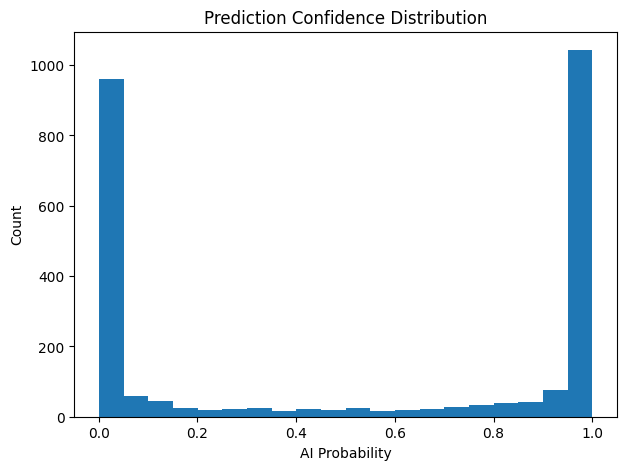

Average confidence: 0.5216


In [27]:
plt.figure(figsize=(7,5))

plt.hist(
    test_df["prob_ai"],
    bins=20
)

plt.title("Prediction Confidence Distribution")
plt.xlabel("AI Probability")
plt.ylabel("Count")
plt.show()

print(
    "Average confidence:",
    round(test_df["prob_ai"].mean(), 4)
)

# Final Conclusions

In this advanced error analysis, we further examined the behavior of the multi-modal RoBERTa model.

The results show that the model often relies on surface-level textual features such as punctuation, hashtags, mentions, and formatting patterns. The confidence distribution also showed that the model usually makes very confident predictions near 0 or 1.

The punctuation masking and class imbalance experiments demonstrated that the model’s behavior can change when shortcut-style features are removed or when the data distribution becomes imbalanced.

Overall, this analysis suggests that the multi-modal RoBERTa framework performs well on the classification task, but future improvements may require reducing dependence on superficial stylistic features and improving semantic understanding.